<a href="https://colab.research.google.com/github/dnanaat/PCVK_Genap_2026/blob/main/Pertemuan_2B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

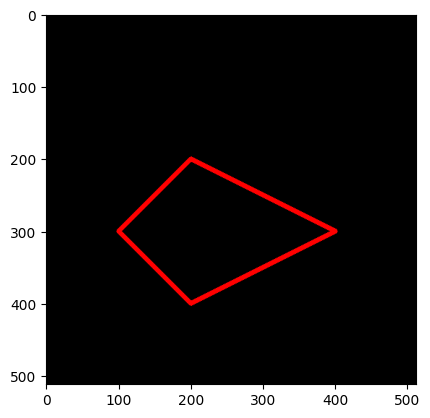

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv

black_img2 = np.zeros(shape=(512,512,3),dtype=np.int32)
plt.imshow(black_img2)

pts = vertices.reshape((-1,1,2)) # nilai 2 untuk menunjukkan bahwa tiap titik dibuat 3 channel yg mewakili R, G, dan B
pts

cv.polylines(black_img2,[pts],isClosed=True,color=(255,0,0),thickness=5)
plt.imshow(black_img2)

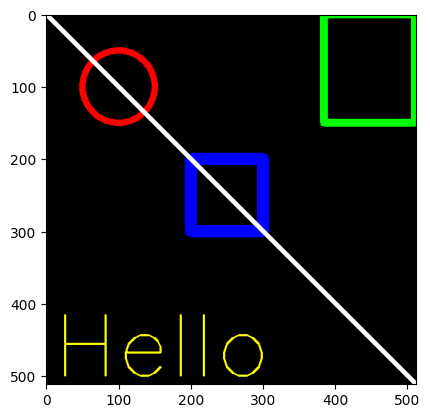

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv

black_img = np.zeros(shape=(512,512,3),dtype=np.int16)
plt.imshow(black_img)

cv.rectangle(black_img,pt1=(384,0),pt2=(510,150),color=(0,255,0),thickness=10)
plt.imshow(black_img)

cv.rectangle(black_img,pt1=(200,200),pt2=(300,300),color=(0,0,255),thickness=15)
plt.imshow(black_img)

cv.circle(black_img,center=(100,100),radius=50,color=(255,0,0),thickness=8)
plt.imshow(black_img)

cv.line(black_img,pt1=(0,0),pt2=(512,512),color=(255,255,255),thickness=5)
plt.imshow(black_img)

font = cv.FONT_HERSHEY_SIMPLEX
cv.putText(black_img,text='Hello',org=(10,500),fontFace=font,fontScale=4,color=(255,255,0),thickness=2,lineType=cv.LINE_AA)
plt.imshow(black_img)

--- TUGAS 1 ---


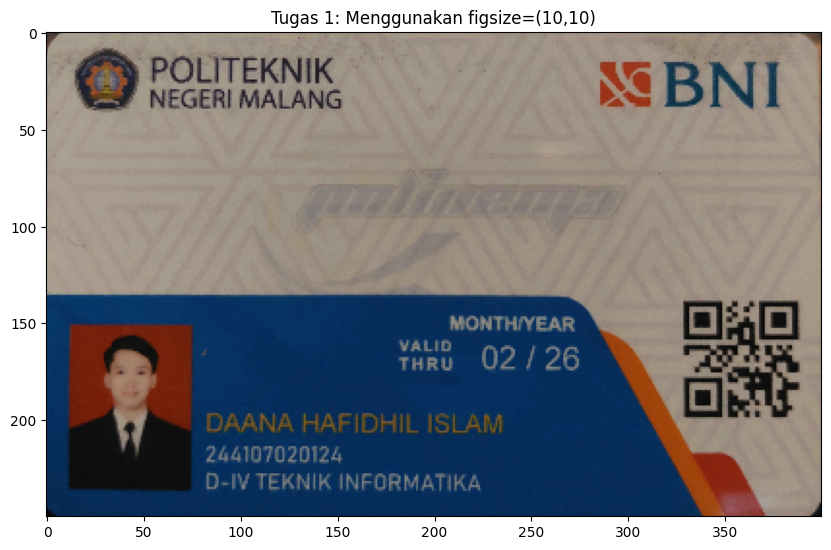


--- TUGAS 2 ---


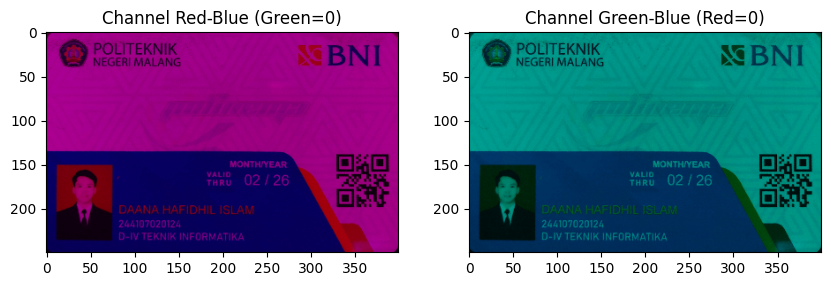


--- TUGAS 3 ---


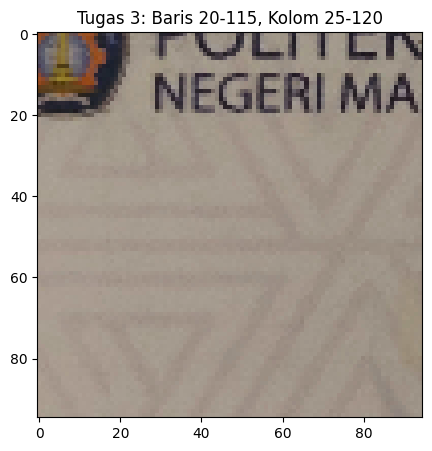


--- TUGAS 4 ---


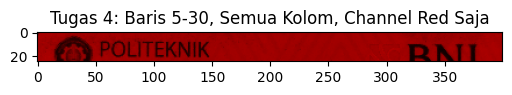


--- TUGAS 5 ---


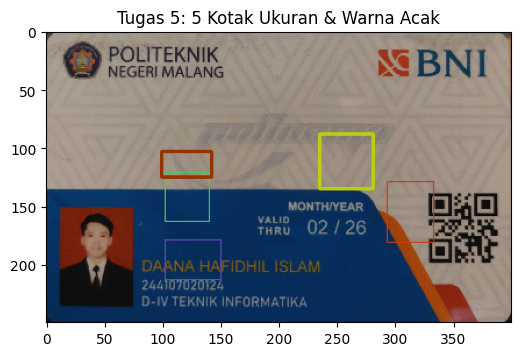


--- TUGAS 6 ---


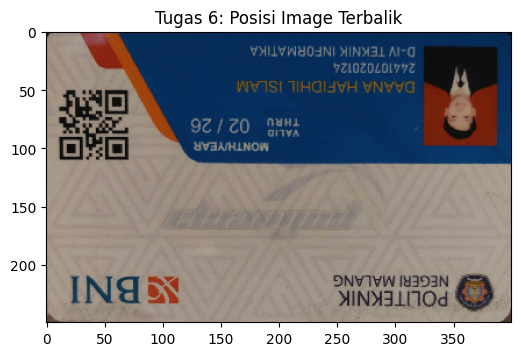


--- TUGAS 7 ---


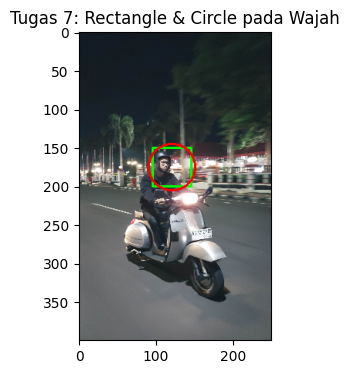


--- TUGAS 8 ---


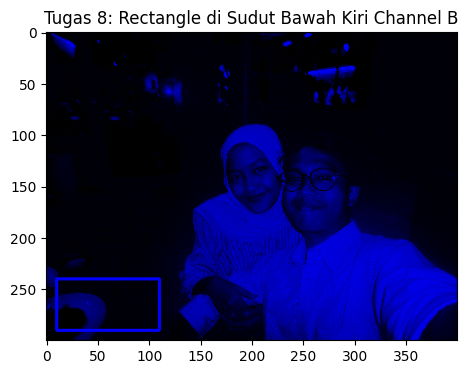


--- TUGAS 9 ---


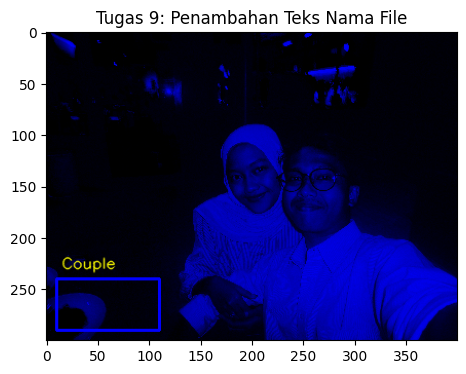

In [84]:
import numpy as np
import pandas as pd
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
from skimage import transform
from PIL import Image
import matplotlib.pylab as plt

img = cv.imread("/content/drive/MyDrive/PCVK/KTM Daana.jpg")
imgRGB = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
imgRGB_small = cv2.resize(imgRGB, (400, 250))

imgVespa = cv.imread("/content/drive/MyDrive/PCVK/vespa.jpg")
imgVespaRGB = cv2.cvtColor(imgVespa, cv2.COLOR_BGR2RGB)
imgVespaRGB_small = cv2.resize(imgVespaRGB, (250, 400))

imgCouple = cv.imread("/content/drive/MyDrive/PCVK/couple.jpg")
imgCoupleRGB = cv2.cvtColor(imgCouple, cv2.COLOR_BGR2RGB)
imgCoupleRGB_small = cv2.resize(imgCoupleRGB, (400, 300))


# TUGAS 1: Menggunakan figsize, perhatikan apakah ukuran image pixelnya berubah?

print("--- TUGAS 1 ---")
fig = plt.figure(figsize=(10, 10)) # Memperbesar ukuran canvas plotter
ax = fig.add_subplot(111)
ax.imshow(imgRGB_small)
plt.title("Tugas 1: Menggunakan figsize=(10,10)")
plt.show()

#-------------------------------------------------------------------------------

# TUGAS 2: Tampilkan image dalam channel Red-Blue dan Green-Blue saja!

print("\n--- TUGAS 2 ---")
# Membuat salinan gambar
img_rb = imgRGB_small.copy()
img_gb = imgRGB_small.copy()

# Channel Red-Blue saja (Green diset 0 / dihilangkan)
img_rb[:, :, 1] = 0

# Channel Green-Blue saja (Red diset 0 / dihilangkan)
img_gb[:, :, 0] = 0

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img_rb)
plt.title("Channel Red-Blue (Green=0)")

plt.subplot(1, 2, 2)
plt.imshow(img_gb)
plt.title("Channel Green-Blue (Red=0)")
plt.show()

#-------------------------------------------------------------------------------

# TUGAS 3: Tampilkan image baris ke 20-115, kolom 25-120!

print("\n--- TUGAS 3 ---")
img_slicing = imgRGB_small[20:115, 25:120]
plt.figure(figsize=(5, 5))
plt.imshow(img_slicing)
plt.title("Tugas 3: Baris 20-115, Kolom 25-120")
plt.show()

#-------------------------------------------------------------------------------

# TUGAS 4: Tampilkan image baris ke 5-30, semua kolom, channel Red saja!

print("\n--- TUGAS 4 ---")
# Ambil baris 5-30 dan semua kolom
img_red_slice = imgRGB_small[5:30, :].copy()
# Nolkan channel Green (index 1) dan Blue (index 2), biarkan Red (index 0)
img_red_slice[:, :, 1] = 0
img_red_slice[:, :, 2] = 0

plt.figure(figsize=(6, 3))
plt.imshow(img_red_slice)
plt.title("Tugas 4: Baris 5-30, Semua Kolom, Channel Red Saja")
plt.show()

#-------------------------------------------------------------------------------

# TUGAS 5: Buat 5 kotak berbagai ukuran dan warna berbeda

print("\n--- TUGAS 5 ---")
img_random_box = imgRGB_small.copy()
h, w, _ = img_random_box.shape

np.random.seed(42) # Agar hasil acak konsisten saat dijalankan
for i in range(5):
    # Titik acak untuk kotak
    x1 = np.random.randint(0, w - 50)
    y1 = np.random.randint(0, h - 50)
    x2 = x1 + np.random.randint(20, 60)
    y2 = y1 + np.random.randint(20, 60)

    # Warna acak RGB
    color = (int(np.random.randint(0, 256)),
             int(np.random.randint(0, 256)),
             int(np.random.randint(0, 256)))

    thickness = np.random.randint(1, 4)
    cv.rectangle(img_random_box, (x1, y1), (x2, y2), color, thickness)

plt.figure(figsize=(6, 4))
plt.imshow(img_random_box)
plt.title("Tugas 5: 5 Kotak Ukuran & Warna Acak")
plt.show()

#-------------------------------------------------------------------------------

# TUGAS 6: Tampilkan image dengan posisi terbalik!

print("\n--- TUGAS 6 ---")
# Fungsi cv2.flip dengan flipCode = -1 (terbalik vertikal dan horizontal) atau 1 (horizontal)
img_flipped = cv2.flip(imgRGB_small, -1)
plt.figure(figsize=(6, 4))
plt.imshow(img_flipped)
plt.title("Tugas 6: Posisi Image Terbalik")
plt.show()

#-------------------------------------------------------------------------------

# TUGAS 7: Buat rectangle dan circle pada bagian wajah dari image foto Anda

print("\n--- TUGAS 7 ---")
img_face = imgVespaRGB_small.copy()

cv.rectangle(img_face, pt1=(95, 150), pt2=(145, 200), color=(0, 255, 0), thickness=2)
cv.circle(img_face, center=(120, 175), radius=30, color=(255, 0, 0), thickness=2)

plt.figure(figsize=(6, 4))
plt.imshow(img_face)
plt.title("Tugas 7: Rectangle & Circle pada Wajah")
plt.show()

#-------------------------------------------------------------------------------

# TUGAS 8: Buat rectangle pada bagian sudut bawah kiri channel B pada color space RGB

print("\n--- TUGAS 8 ---")
# Mengambil channel Blue (index 2 dari RGB)
img_b_channel = imgCoupleRGB_small.copy()
img_b_channel[:, :, 0] = 0 # Nolkan Red
img_b_channel[:, :, 1] = 0 # Nolkan Green

# Membuat rectangle di sudut bawah kiri
h_img, w_img, _ = img_b_channel.shape
cv.rectangle(img_b_channel, pt1=(10, h_img - 60), pt2=(110, h_img - 10), color=(0, 0, 255), thickness=2)

plt.figure(figsize=(6, 4))
plt.imshow(img_b_channel)
plt.title("Tugas 8: Rectangle di Sudut Bawah Kiri Channel B")
plt.show()

#-------------------------------------------------------------------------------

# TUGAS 9: Lengkapi tulisan nama file pada citra dari soal no.8

print("\n--- TUGAS 9 ---")
font = cv.FONT_HERSHEY_SIMPLEX
img_text = img_b_channel.copy()
cv.putText(img_text, text='Couple', org=(15, h_img - 70), fontFace=font, fontScale=0.5, color=(255, 255, 0), thickness=1, lineType=cv.LINE_AA)

plt.figure(figsize=(6, 4))
plt.imshow(img_text)
plt.title("Tugas 9: Penambahan Teks Nama File")
plt.show()

Silakan pilih dan upload file gambar KTM:


Saving KTM_Daana.jpg to KTM_Daana (3).jpg
File berhasil di-upload: KTM_Daana (3).jpg


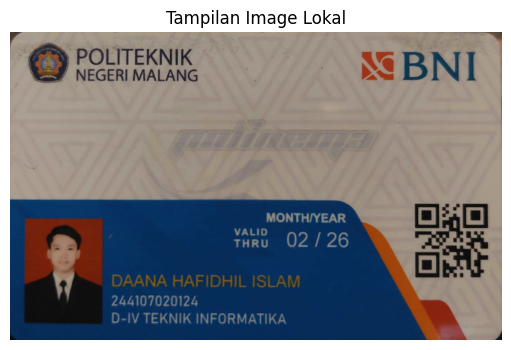

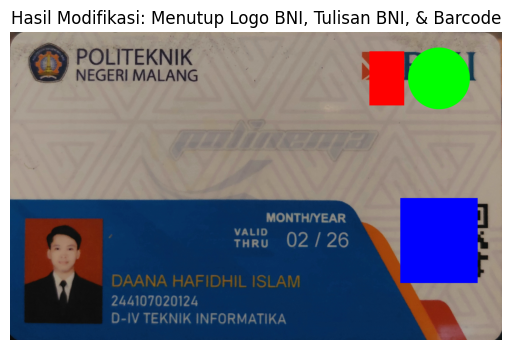

In [88]:
import numpy as np
import pandas as pd
import cv2 as cv
from google.colab import files
from google.colab.patches import cv2_imshow
import matplotlib.pylab as plt

print("Silakan pilih dan upload file gambar KTM:")
uploaded = files.upload()

for fn in uploaded.keys():
    nama_file = fn
    print(f"File berhasil di-upload: {nama_file}")

img = cv.imread(nama_file)
imgRGB = cv.cvtColor(img, cv.COLOR_BGR2RGB)

plt.figure(figsize=(7, 4))
plt.imshow(imgRGB)
plt.title("Tampilan Image Lokal")
plt.axis("off")
plt.show()

img_kelompok = imgRGB.copy()

# ------------------------------------------

# 1. Logo/simbol BNI
cv.rectangle(img_kelompok,pt1=(4650, 250),pt2=(5100, 950),color=(255, 0, 0),thickness=-1)

# ------------------------------------------

# 2. Tulisan BNI
# Lingkaran HIJAU
cv.circle(img_kelompok,center=(5550, 600),radius=400,color=(0, 255, 0),thickness=-1)

# ------------------------------------------

# 3. Barcode / QR Code
# Persegi panjang BIRU
cv.rectangle(img_kelompok,pt1=(5050, 2150),pt2=(6050, 3250),color=(0, 0, 255),thickness=-1)

# HASIL
plt.figure(figsize=(7, 4))
plt.imshow(img_kelompok)
plt.title("Hasil Modifikasi: Menutup Logo BNI, Tulisan BNI, & Barcode")
plt.axis("off")
plt.show()